# Newton mapping

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import qpmr
from matplotlib.colors import ListedColormap
import qpmr.plot
from qpmr.quasipoly import derivative, eval # TODO eval name
import qpmr.quasipoly.examples as examples

In [2]:
"""
Settings shared among all plots
"""
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import pathlib
import os


plt.rcParams.update({
    "font.size": 12,            # Default font size
    "axes.titlesize": 14,       # Axes title font size
    "axes.labelsize": 12,       # X/Y axis labels
    "xtick.labelsize": 10,      # X tick labels
    "ytick.labelsize": 10,      # Y tick labels
    "legend.fontsize": 10,      # Legend font size
    "figure.titlesize": 16,     # Figure title
    "text.usetex": True,
    "font.family": "serif",
})

# TWO column article -> LINE_WIDTH = one column width
LINE_WIDTH = 360.0 / 72 # 1 pt = 1/72 inches

FIG_SIZE_SIMPLE = (LINE_WIDTH, LINE_WIDTH * 0.75)


# TODO save figure routine
def save_figure(fig: Figure, name: str, path: os.PathLike[str]=None, **kwargs) -> None:
    default_kwargs = {"bbox_inches": "tight"}
    if path is None:
        fname = pathlib.Path(f"{name}.pdf")
    else:
        fname = pathlib.Path(path) / f"{name}.pdf"
    print(f"Saving figure: '{fname}'")
    fig.savefig(fname=fname, **(default_kwargs | kwargs))

In [3]:
coefs, delays = examples.vyhlidal2014qpmr(1)
# coefs, delays = examples.vyhlidal2014qpmr(3)
dcoefs, ddelays = derivative(coefs, delays)

N = 2000
region = (-18, 2, 0, 20)
region = (-0.3, 0.3, 4.7, 5.3)
region = (-4, 4, 0, 16)

extended_region = [region[0] - 10, region[1] + 10, region[2] - 10, region[3] + 10]

roots, info = qpmr.qpmr(coefs, delays, region=extended_region)

# Newton map
real_range = np.linspace(region[0], region[1], N)
imag_range = np.linspace(region[2], region[3], N)


z = 1j*np.linspace(region[2], region[3], N).reshape(-1, 1) + np.linspace(region[0], region[1], N)
z0 = z.copy()

newton_steps = np.zeros_like(z, dtype=np.complex128)
iter_count = np.zeros_like(z, dtype=int)

max_iter = 20
tol = 1e-6

for i in range(max_iter):
    fz = eval(coefs, delays, z)
    dfz = eval(dcoefs, ddelays, z)

    mask = np.isnan(z) | (np.abs(dfz) < 1e-12)  # TODO tolerance for zero derivative
    z[mask] = np.nan
    newton_steps[~mask] = fz[~mask] / dfz[~mask]
    z[~mask] = z[~mask] - newton_steps[~mask]

    mask_converged = np.abs(newton_steps) < tol
    iter_count[~mask_converged] += 1
    print(f"Iteration {i+1}/{max_iter}, converged points: {np.sum(mask_converged)}, problematic points: {np.sum(mask)}")


c:\Users\apeichl\source\qpmr\.venv\Lib\site-packages\numpy\ma\core.py:2896: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Iteration 1/20, converged points: 0, problematic points: 0


C:\Users\apeichl\source\qpmr\src\qpmr\quasipoly\core.py:47: RuntimeWarning: overflow encountered in exp
  dels = np.exp(- s[..., np.newaxis] * delays[np.newaxis, ...])
C:\Users\apeichl\source\qpmr\src\qpmr\quasipoly\core.py:48: RuntimeWarning: invalid value encountered in multiply
  aa = dels[..., np.newaxis] * coefs.T[np.newaxis, ...] # (..., n_delays, order)
C:\Users\apeichl\AppData\Local\Temp\ipykernel_16628\3253320686.py:34: RuntimeWarning: invalid value encountered in divide
  newton_steps[~mask] = fz[~mask] / dfz[~mask]


Iteration 2/20, converged points: 2, problematic points: 0
Iteration 3/20, converged points: 857, problematic points: 4776


C:\Users\apeichl\source\qpmr\src\qpmr\quasipoly\core.py:47: RuntimeWarning: invalid value encountered in exp
  dels = np.exp(- s[..., np.newaxis] * delays[np.newaxis, ...])


Iteration 4/20, converged points: 33489, problematic points: 6638
Iteration 5/20, converged points: 243856, problematic points: 63717
Iteration 6/20, converged points: 773399, problematic points: 94335
Iteration 7/20, converged points: 1454744, problematic points: 129300
Iteration 8/20, converged points: 2098749, problematic points: 155334
Iteration 9/20, converged points: 2564576, problematic points: 169177
Iteration 10/20, converged points: 2883337, problematic points: 178387
Iteration 11/20, converged points: 3102144, problematic points: 184073
Iteration 12/20, converged points: 3253187, problematic points: 188010
Iteration 13/20, converged points: 3360590, problematic points: 190733
Iteration 14/20, converged points: 3438729, problematic points: 192814
Iteration 15/20, converged points: 3496194, problematic points: 194320
Iteration 16/20, converged points: 3537993, problematic points: 195573
Iteration 17/20, converged points: 3569268, problematic points: 196547
Iteration 18/20, con

In [5]:
nroots = len(roots)

dist = np.abs(z[..., None] - roots)
dist_min = np.min(dist, axis=-1) # minimum distance
closest_root = np.argmin(dist, axis=-1)

z
cluster_idx = np.full(z.shape, np.nan, dtype=float)

valid = ~np.isnan(z)
cluster_idx[valid] = np.argmin(
    np.abs(z[valid][:, None] - roots[None, :]),
    axis=1
).astype(float)

C:\Users\apeichl\AppData\Local\Temp\ipykernel_16628\697839660.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', nroots)


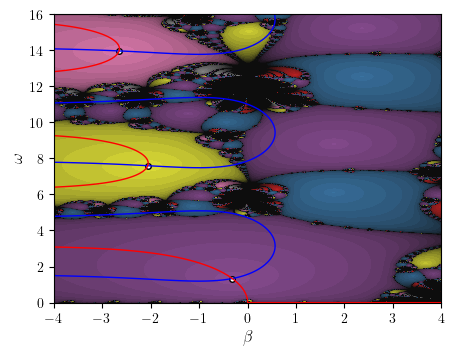

In [ ]:

import matplotlib.pyplot as plt

cmap = plt.cm.get_cmap('Set1', nroots)
img = np.zeros((*z.shape, 3))

norm_iter = iter_count / max_iter

for k in range(nroots):
    mask = (closest_root == k) & (dist_min < 0.01)
    for c in range(3):
        img[mask, c] = cmap(k)[c] * (1. - norm_iter[mask])

img[~(dist_min < 0.01), :] = 1.0
img[~mask_converged, :] = 0.0


img = np.zeros((*z.shape, 3))

norm_iter = iter_count / max_iter

for k in range(np.max(cluster_idx[~np.isnan(cluster_idx)]).astype(int) + 1):
    mask = (cluster_idx == k) & ~np.isnan(cluster_idx)
    for c in range(3):
        img[mask, c] = cmap(k)[c] * (1. - norm_iter[mask])

# img[~(dist_min < 0.01), :] = 1.0
#img[~mask_converged, :] = 0.0

roots_to_plot = roots[(roots.real >= region[0]) & (roots.real <= region[1]) & (roots.imag >= region[2]) & (roots.imag <= region[3])]
fig, ax = plt.subplots(figsize=FIG_SIZE_SIMPLE)
ax.imshow(img, extent=[region[0], region[1], region[2], region[3]], 
            origin='lower', aspect='auto', interpolation='nearest',
            rasterized=True, alpha=0.95)
# cluster_idx[~mask_converged] = np.nan
# ax.imshow(mask_converged.astype(float), cmap='gray', origin='lower', aspect='auto',
#           extent=[region[0], region[1], region[2], region[3]], alpha=0.9)
# ax.imshow(cluster_idx, extent=[region[0], region[1], region[2], region[3]], origin='lower', aspect='auto')


# plot contours
fz = eval(coefs, delays, z0)
ax.contour(real_range, imag_range, fz.real, levels=[0], colors='blue', linewidths=1)
ax.contour(real_range, imag_range, fz.imag, levels=[0], colors='red', linewidths=1)

# plot roots inside region
ax.scatter(roots_to_plot.real, roots_to_plot.imag, color='black', facecolors='black', 
            s=16, edgecolors='black')


ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$\omega$')

plt.show()

In [88]:
save_figure(fig, "newton_basin_fractal")

Saving figure: 'newton_basin_fractal.pdf'


In [7]:
binary_mask = dist_min < 0.01

fig, (ax, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax.imshow(binary_mask, cmap='gray', origin='lower', aspect='auto',
          extent=[region[0], region[1], region[2], region[3]])
ax.set_xlabel('β')
ax.set_ylabel('ω')
ax.set_title('Binary Mask: dist_min < 0.01')
ax2.imshow(mask_converged, cmap='gray', origin='lower', aspect='auto',
          extent=[region[0], region[1], region[2], region[3]])
ax2.set_xlabel('β')
ax2.set_ylabel('ω')
ax2.set_title('Converged Points')
plt.show()

RuntimeError: latex was not able to process the following string:
b'\\u03c9'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (MiKTeX 24.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-04>
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\apeichl\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\apeichl\AppData\Local\Programs\MiKT

<Figure size 1200x500 with 2 Axes>

In [ ]:
mask_converged